## Manuel Ramallo, Lucía Pérez, Alexandre Lorenzo

# Implementación dunha arquitectura MLP modular


In [1]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126 -q
!pip3 install scikit-image -q
import torch
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import random_split

import copy
from skimage.feature import hog
from skimage.color import rgb2gray

import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import confusion_matrix
import numpy as np
import random
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score


torch.manual_seed(1)
random.seed(1)
np.random.seed(1)

In [2]:

def plot_confusion_matrix(y_true, y_pred, labels_map):
    conf_matrix = confusion_matrix(y_true, y_pred)
    conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(10, 10))
    plt.imshow(conf_matrix_normalized, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion matrix')
    plt.colorbar()
    tick_marks = np.arange(10)
    plt.xticks(tick_marks, labels_map.values(), rotation=45)
    plt.yticks(tick_marks, labels_map.values())

    thresh = conf_matrix.max() / 2.
    for i in range(conf_matrix.shape[0]):
        for j in range(conf_matrix.shape[1]):
            plt.text(j, i, f"{conf_matrix[i, j]}", 
                    horizontalalignment="center",
                    color="white" if conf_matrix[i, j] > thresh else "black")

    plt.ylabel('Clase real')
    plt.xlabel('Clase predicida')
    plt.show()

def get_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [3]:
class MLP(nn.Module):

    def __init__(self, input_neurons, output_neurons, hidden_layers):
        
        super(MLP, self).__init__()
        self.flatten = nn.Flatten()
        
        # Lista para almacenar capas
        self.layers = nn.ModuleList()
        
        # Engadimos a primeira capa (Entrada -> Primeira capa oculta)
        # Se a lista de ocultas está vacía, conectamos entrada con saída directamente
        if len(hidden_layers) > 0:
            self.layers.append(nn.Linear(input_neurons, hidden_layers[0]))
            
            # Engadimos as capas ocultas intermedias
            # Percorremos dende a primeira oculta ata a penúltima
            for i in range(len(hidden_layers) - 1):
                self.layers.append(nn.Linear(hidden_layers[i], hidden_layers[i+1]))
            
            # Engadimos a última capa (Última oculta -> Saída)
            self.layers.append(nn.Linear(hidden_layers[-1], output_neurons))
        else:
            # Caso especial: Se non hai capas ocultas
            self.layers.append(nn.Linear(input_neurons, output_neurons))

        # Definimos as funcións de activación
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)


    def forward(self, x):
        
        x = self.flatten(x)
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:
                x = self.relu(x)
        
        return x

### Implementación CNN modular

In [4]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, num_conv_layers, first_layer_filters, kernel_size, norm):
        super(ConvBlock, self).__init__()

        layers = []
        in_ch = in_channels

        for i in range(num_conv_layers):
            out_ch = first_layer_filters * (2 ** i)

            layers.append(nn.Conv2d(in_ch, out_ch, kernel_size, padding=1))

            if norm:
                layers.append(nn.BatchNorm2d(out_ch))

            layers.append(nn.ReLU())
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))

            in_ch = out_ch  # Actualizo los in_channels para la siguiente capa

        self.block = nn.Sequential(*layers)
        out_ch = first_layer_filters * (2 ** (num_conv_layers - 1))
        self.last_filters = out_ch

    def forward(self, x):
        return self.block(x)


class FCBlock(nn.Module):
    def __init__(self, in_features, hidden_mlp_layers, output_neurons):
        super(FCBlock, self).__init__()

        layers = []
        for hidden_size in hidden_mlp_layers:
            layers.append(nn.Linear(in_features, hidden_size))
            layers.append(nn.ReLU())
            in_features = hidden_size

        layers.append(nn.Linear(in_features, output_neurons))
        # Sin Softmax (CrossEntropyLoss lo incluye internamente)

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

In [5]:
class ModuleCNN(nn.Module):
    def __init__(self, init_h, init_w, in_channels, num_conv_layers, first_layer_filters,
                 kernel_size, norm, hidden_mlp_layers, output_neurons):
        super(ModuleCNN, self).__init__()

        self.conv = ConvBlock(in_channels, num_conv_layers, first_layer_filters, kernel_size, norm)

        # Cálculo a mano del tamaño de la salida del bloque convolucional (alternativa al dummy)
        h, w = init_h, init_w
        for _ in range(num_conv_layers):
            # conv
            h = (h+2) - kernel_size + 1 # padding de 1, stride de 1
            w = (w+2) - kernel_size + 1
            # pooling
            h = h //2
            w = w //2
        flat_size = self.conv.last_filters * h * w

        self.fc = FCBlock(flat_size, hidden_mlp_layers, output_neurons)

    def forward(self, x):
        x = self.conv(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

In [6]:
cnn = ModuleCNN(init_h=160, init_w=160, in_channels=3, num_conv_layers=5, first_layer_filters=8,
                kernel_size=3, norm=True, hidden_mlp_layers=[128], output_neurons=10)
print(f"O modelo ten {get_parameters(cnn):,} parámetros")

O modelo ten 509,898 parámetros


## Optimización de MLP nun problema real

### Extración de datasets

In [7]:
full_train_data = datasets.Imagenette(root="data/", split="train", size="160px", download=True, transform=transforms.Compose([
    transforms.Resize((80, 80)),
    transforms.ToTensor(),
]))
test_data       = datasets.Imagenette(root="data/", split="val",   size="160px", download=True, transform=transforms.Compose([
    transforms.Resize((80, 80)),
    transforms.ToTensor(),
]))
print(f"Total de imaxes de adestramento: {len(full_train_data)}")
print(f"Total de imaxes de test: {len(test_data)}")
train_size = int(0.85 * len(full_train_data))
val_size   = len(full_train_data) - train_size
train_dataset, val_dataset = random_split(full_train_data, [train_size, val_size])

batch_size = 8
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_dataloader  = DataLoader(test_data,     batch_size=batch_size, shuffle=False)

print(f"Número de lotes de adestramento: {len(train_dataloader)}")
print(f"Número de lotes de validación: {len(val_dataloader)}")
print(f"Número de lotes de test: {len(test_dataloader)}")
for batch_imgs, batch_labels in train_dataloader:
    print(f"Tamaño das imaxes: {batch_imgs.size()} - Etiquetas: {batch_labels}")
    break # Paramos o bucle, xa que só queremos ver un lote

100%|██████████| 99.0M/99.0M [00:01<00:00, 59.9MB/s]


Total de imaxes de adestramento: 9469
Total de imaxes de test: 3925
Número de lotes de adestramento: 1006
Número de lotes de validación: 178
Número de lotes de test: 491
Tamaño das imaxes: torch.Size([8, 3, 80, 80]) - Etiquetas: tensor([5, 3, 5, 0, 4, 9, 7, 7])


Probaremos as seguintes configuracións de neuronas en capas ocultas:
 - 3 capas: [1024, 512, 256]
 - 3 capas, pero con máis neuronas: [2048, 1024, 512]
 - Profunda, con repetición de número de neuronas en capas consecutivas: [1024, 1024, 512, 512, 256, 256]

#### Posibles hiperparámetros CNN:
- learning rate -> fijo
- optimizer -> fijo
- n capas 
- n neuronas
- n filtros
- n epochs -> fijo?
- tam lotes -> fijo
- ¿padding,tam kernel en convolución? -> fijo

In [9]:
mlps = [{"model": MLP(input_neurons=80*80*3, output_neurons=10, hidden_layers=[256]), "lr": 1e-3, "optimizer": "Adam"},
        {"model": MLP(input_neurons=80*80*3, output_neurons=10, hidden_layers=[512]), "lr": 1e-3, "optimizer": "Adam"},
        {"model": MLP(input_neurons=80*80*3, output_neurons=10, hidden_layers=[1024, 512]), "lr": 1e-3, "optimizer": "Adam"}, 
        {"model": MLP(input_neurons=80*80*3, output_neurons=10, hidden_layers=[512, 256]), "lr": 1e-3, "optimizer": "Adam"},
        {"model": MLP(input_neurons=80*80*3, output_neurons=10, hidden_layers=[1024, 512, 256]), "lr": 1e-3, "optimizer": "Adam"},
        {"model": MLP(input_neurons=80*80*3, output_neurons=10, hidden_layers=[512, 256]), "lr": 1e-2, "optimizer": "Adam"},
        {"model": MLP(input_neurons=80*80*3, output_neurons=10, hidden_layers=[512]), "lr": 1e-2, "optimizer": "Adam"},
        {"model": MLP(input_neurons=80*80*3, output_neurons=10, hidden_layers=[256]), "lr": 1e-3, "optimizer": "SGD"},
        {"model": MLP(input_neurons=80*80*3, output_neurons=10, hidden_layers=[512]), "lr": 1e-3, "optimizer": "SGD"},
        {"model": MLP(input_neurons=80*80*3, output_neurons=10, hidden_layers=[1024, 512]), "lr": 1e-3, "optimizer": "SGD"}, 
        {"model": MLP(input_neurons=80*80*3, output_neurons=10, hidden_layers=[512, 256]), "lr": 1e-3, "optimizer": "SGD"},
        {"model": MLP(input_neurons=80*80*3, output_neurons=10, hidden_layers=[1024, 512, 256]), "lr": 1e-3, "optimizer": "SGD"},
        {"model": MLP(input_neurons=80*80*3, output_neurons=10, hidden_layers=[512, 256]), "lr": 1e-2, "optimizer": "SGD"},
        {"model": MLP(input_neurons=80*80*3, output_neurons=10, hidden_layers=[512]), "lr": 1e-2, "optimizer": "SGD"}
]

configs_cnn = [
    # ── Baseline ──────────────────────────────────────────────────
    {"cnn_params": {"num_conv_layers": 3, "first_layer_filters": 8,  "hidden_mlp_layers": [128]},       "lr": 1e-3},

    # ── Más profundidad convolucional ──────────────────────────────
    {"cnn_params": {"num_conv_layers": 4, "first_layer_filters": 8,  "hidden_mlp_layers": [128]},       "lr": 1e-3},
    {"cnn_params": {"num_conv_layers": 5, "first_layer_filters": 8,  "hidden_mlp_layers": [128]},       "lr": 1e-3},

    # ── Más filtros ────────────────────────────────────────────────
    {"cnn_params": {"num_conv_layers": 3, "first_layer_filters": 16, "hidden_mlp_layers": [128]},       "lr": 1e-3},
    {"cnn_params": {"num_conv_layers": 4, "first_layer_filters": 16, "hidden_mlp_layers": [128]},       "lr": 1e-3},

    # ── Dos capas FC ───────────────────────────────────────────────
    {"cnn_params": {"num_conv_layers": 3, "first_layer_filters": 8,  "hidden_mlp_layers": [256, 128]},  "lr": 1e-3},
    {"cnn_params": {"num_conv_layers": 4, "first_layer_filters": 16, "hidden_mlp_layers": [256, 128]},  "lr": 1e-3},

    # ── Learning rate más bajo ─────────────────────────────────────
    {"cnn_params": {"num_conv_layers": 4, "first_layer_filters": 16, "hidden_mlp_layers": [128]},       "lr": 1e-4},
    {"cnn_params": {"num_conv_layers": 4, "first_layer_filters": 16, "hidden_mlp_layers": [256, 128]},  "lr": 1e-4},
]


loss_fn = nn.CrossEntropyLoss()

#### Funcións de adestramento e test

In [14]:
def train(dataloader, model, loss_fn, optimizer):
    # Obtemos o número total de lotes
    num_images = len(dataloader.dataset)
    # Poñemos o modelo en modo de adestramento
    model.train()
    # Iteramos sobre os lotes
    n_batch = 0
    for batch_imgs, batch_labels in dataloader:
        # Obtemos as predicións para o lote actual
        batch_predicted_probabilities = model(batch_imgs)
        # Calculamos a perda
        loss = loss_fn(batch_predicted_probabilities, batch_labels)
        # Poñemos a cero os gradientes dos parámetros do modelo
        optimizer.zero_grad()
        # Realizamos a retropropagación para calcular os gradientes de cada parámetro
        loss.backward()
        # Actualizamos os parámetros do modelo utilizando os gradientes calculados
        optimizer.step()

        # Cada 100 lotes, imprimimos a perda e o progreso
        if n_batch % 200 == 0 and n_batch > 0:
            loss, imgs_processed = loss.item(), n_batch * len(batch_imgs)
            print(f"perda: {loss:>7f}  [{imgs_processed:>5d}/{num_images:>5d}]")

        n_batch += 1

    return loss

def test(dataloader, model):
    # Obtemos o número total de imaxes
    num_images = len(dataloader.dataset)
    # Poñemos o modelo en modo de avaliación (sen calcular gradientes)
    model.eval()
    # Inicializamos as variables para gardar a perda e a precisión
    test_loss, correct = 0, 0
    # Inicializamos as listas para gardar as clases predicidas e as clases reais
    test_predicted_classes, test_true_classes = [], []
    with torch.no_grad():
        for batch_imgs, batch_labels in dataloader:
            # Obtemos as predicións para o lote actual
            batch_predicted_probabilities = model(batch_imgs)
            # Calculamos a perda e acumulamos o valor
            test_loss += loss_fn(batch_predicted_probabilities, batch_labels).item()
            # Calculamos as clases predicidas (aquelas con maior probabilidade)
            batch_predicted_classes = batch_predicted_probabilities.argmax(dim=1)
            # Obtemos o número de predicións correctas e acumulamos o valor
            correct += (batch_predicted_classes == batch_labels).sum().item()
            # Gardamos as clases predicidas e as clases reais. Precisamos convertelas a listas de Python coa función tolist()
            test_predicted_classes.extend(batch_predicted_classes.tolist())
            test_true_classes.extend(batch_labels.tolist())
    # Calculamos a perda media e o porcentaxe de predicións correctas (accuracy), dividindo entre o número total de imaxes 
    test_loss /= num_images
    correct /= num_images
    print(f"Perda media: {test_loss:>8f} Accuracy: {correct*100:>0.1f}%\n")

    return test_loss,test_predicted_classes, test_true_classes

### Bucles de execución

#### Execución modelos MLP

In [13]:
best_global_val_loss = float('inf')
best_global_model    = None
best_global_cfg      = None
results_mlp = []

for config in mlps:
    mlp = config["model"]
    learning_rate = config["lr"]
    optimizer_name = config["optimizer"]
    train_losses_mlp = []
    val_losses_mlp = []
    epochs = 1
    best_val_loss = float('inf')
    best_model = None
    patience = 3
    current_patience = 0

    if optimizer_name == "SGD":
        optimizer = torch.optim.SGD(mlp.parameters(), lr=learning_rate)
    elif optimizer_name == "Adam":
        optimizer = torch.optim.Adam(mlp.parameters(), lr=learning_rate)

    for t in range(epochs):
        print(f"Epoch {t+1}\n-------------------------------")
        train_loss = train(train_dataloader, mlp, loss_fn, optimizer)
        train_losses_mlp.append(train_loss.item())

        val_loss = test(val_dataloader, mlp)[0]
        val_losses_mlp.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = copy.deepcopy(mlp.state_dict())
            current_patience = 0
        else:
            current_patience += 1
            if current_patience >= patience:
                print("Early stopping")
                break

    mlp.load_state_dict(best_model)

    # Evaluar en test
    _, test_predicted, test_true = test(test_dataloader, mlp)
    acc       = accuracy_score(test_true, test_predicted)
    precision = precision_score(test_true, test_predicted, average='macro')
    recall    = recall_score(test_true, test_predicted, average='macro')
    f1        = f1_score(test_true, test_predicted, average='macro')

    results_mlp.append({
        "optimizer":     optimizer_name,
        "lr":            learning_rate,
        "params_mlp":    get_parameters(mlp),
        "val_loss":      best_val_loss,
        "accuracy":      acc,
        "precision":     precision,
        "recall":        recall,
        "f1":            f1,
        "train_losses":  train_losses_mlp,
        "val_losses":    val_losses_mlp,
    })

    # Comprobamos se é o mellor modelo global
    if best_val_loss < best_global_val_loss:
        best_global_val_loss = best_val_loss
        best_global_model    = copy.deepcopy(mlp.state_dict())
        best_global_cfg      = config
        print(f"Novo mellor modelo global (val_loss={best_val_loss:.6f})")

# Tabla resumen
results_mlp_df = pd.DataFrame(results_mlp).drop(columns=["train_losses", "val_losses"])
print(results_mlp_df)

Epoch 1
-------------------------------
perda: 1.919879  [  800/ 8048]
perda: 2.301411  [ 1600/ 8048]


KeyboardInterrupt: 

In [ ]:
def train_with_early_stopping_cnn(model, train_dataloader, val_dataloader, 
                               epochs=20, patience=3, lr=1e-3, optimizer_name="Adam"):
    loss_fn   = nn.CrossEntropyLoss()
    if optimizer_name == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss    = float('inf')
    best_model_state = None
    current_patience = 0
    train_losses, val_losses = [], []

    for t in range(epochs):
        print(f"\nEpoch {t+1}/{epochs}\n{'-'*35}")
        train_loss = train(train_dataloader, model, loss_fn, optimizer)
        train_losses.append(train_loss.item())

        val_loss, _, _ = test(val_dataloader, model, loss_fn)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            current_patience = 0
            print("Mellor modelo gardado")
        else:
            current_patience += 1
            print(f"  Paciencia: {current_patience}/{patience}")
            if current_patience >= patience:
                print(f"Early stopping activado")
                break

    model.load_state_dict(best_model_state)
    return model, best_val_loss, train_losses, val_losses

In [ ]:
best_global_val_loss = float('inf')
best_global_model    = None
results_cnn = []

for cfg in configs_cnn:
    print(f"\n{'='*50}")
    print(f"Config: {cfg}")

    model = ModuleCNN(init_h=80, init_w=80, in_channels=3,
                kernel_size=3, norm=True, output_neurons=10, **cfg["cnn_params"])
    print(f"Parámetros: {get_parameters(model):,}")
    model, best_val_loss, train_losses, val_losses = train_with_early_stopping_cnn(
        model, train_dataloader, val_dataloader, epochs=20, patience=3, lr=cfg["lr"]
    )

    # Evaluar en test
    loss_fn = nn.CrossEntropyLoss()
    _, test_predicted, test_true = test(test_dataloader, model, loss_fn)
    acc = accuracy_score(test_true, test_predicted)
    precision = precision_score(test_true, test_predicted, average='macro')
    recall = recall_score(test_true, test_predicted, average='macro')
    f1  = f1_score(test_true, test_predicted, average='macro')

    results_cnn.append({**cfg, "params": get_parameters(model),
                    "val_loss": best_val_loss, "accuracy": acc, "precision": precision,
                    "recall": recall, "f1": f1, "train_losses": train_losses, "val_losses": val_losses})

    # Actualizar mejor modelo global (comparando por val_loss)
    if best_val_loss < best_global_val_loss:
        best_global_val_loss = best_val_loss
        best_global_model    = copy.deepcopy(model.state_dict())
        print(f"Novo mellor modelo global (val_loss={best_val_loss:.6f})")
        best_global_cfg = cfg

# Mostrar tabla resumen
results_cnn_df = pd.DataFrame(results_cnn).drop(columns=["train_losses", "val_losses"])
print(results_cnn_df)

## VISUALIZACIÓN DE RESULTADOS

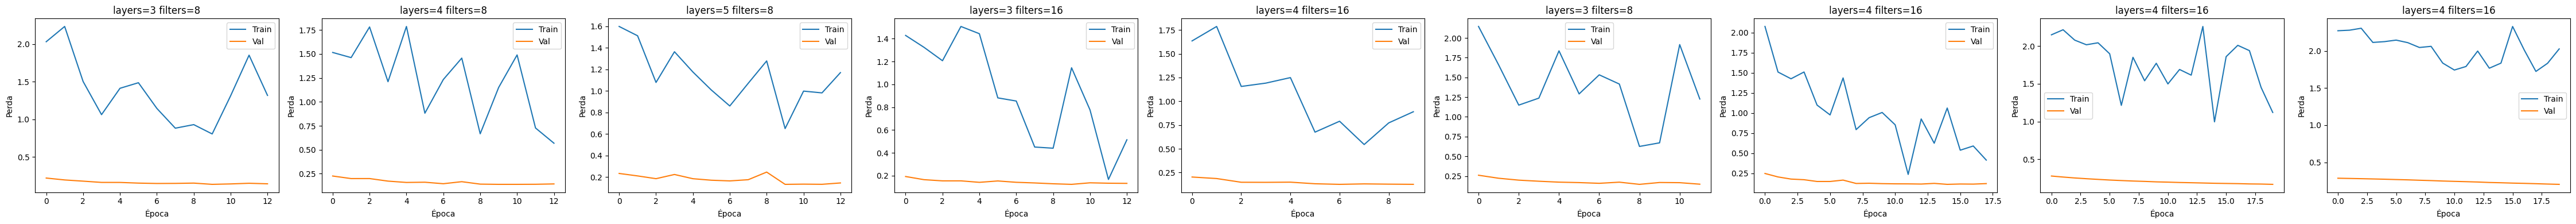

In [ ]:
n = len(results_mlp)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), sharey=True)
if n == 1:
    axes = [axes]

for ax, r in zip(axes, results_mlp):
    epochs_ran = range(1, len(r["train_losses"]) + 1)
    ax.plot(epochs_ran, r["train_losses"], label="Train", marker="o", markersize=3)
    ax.plot(epochs_ran, r["val_losses"],   label="Val",   marker="o", markersize=3)
    ax.set_title(
        f"model: {r['model']}, optimizer: {r['optimizer']}, lr: {r['lr']}\n"
        f"acc={r['accuracy']*100:.1f}%",
        fontsize=9
    )
    ax.set_xlabel("Época")
    ax.set_ylabel("Perda")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Curvas de aprendizaxe por configuración", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

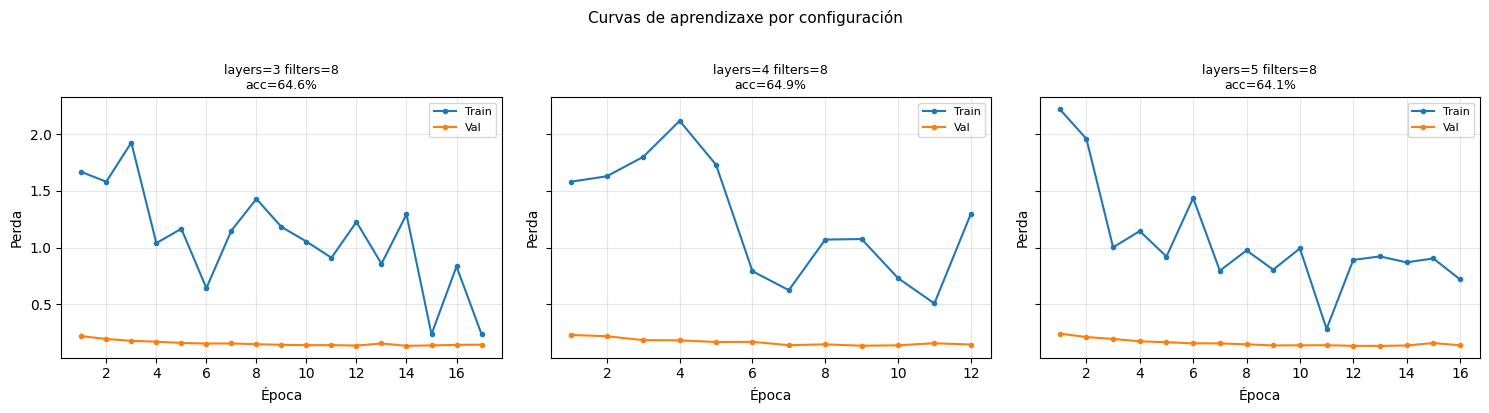

In [ ]:
n = len(results_cnn)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), sharey=True)
if n == 1:
    axes = [axes]

for ax, r in zip(axes, results_cnn):
    epochs_ran = range(1, len(r["train_losses"]) + 1)
    ax.plot(epochs_ran, r["train_losses"], label="Train", marker="o", markersize=3)
    ax.plot(epochs_ran, r["val_losses"],   label="Val",   marker="o", markersize=3)
    ax.set_title(
        f"layers={r['num_conv_layers']} filters={r['first_layer_filters']}\n"
        f"acc={r['accuracy']*100:.1f}%",
        fontsize=9
    )
    ax.set_xlabel("Época")
    ax.set_ylabel("Perda")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Curvas de aprendizaxe por configuración", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()